<a href="https://colab.research.google.com/github/MatchLab-Imperial/deep-learning-course/blob/master/04_Common_CNN_architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to common Convolutional Neural Networks Architectures
In this tutorial, we will learn about well-known CNN architectures in the field of computer vision and how to implement them in Pytorch. Moreover, we will show that some of the standard architectures are already available into the Pytorch framework. Finally, we will see how we can import and use them in our code.






In [ ]:
!pip in9stall torchinfo

In [ ]:
# Packages
import cv2
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, TensorDataset, Subset
import torchinfo
import torchvision
from torchvision import models
from torchvision import transforms


# Global variables
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Utility functions
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_classifier(num_epochs, data_loader, model, criterion, optimizer, device=DEVICE):
    model = model.to(device)
    print(
        f"Training on {device}: {len(data_loader.dataset)} images, "
        f"{len(data_loader)} batches/epoch",
        flush=True,
    )

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        progress_every = max(1, len(data_loader) // 10)
        epoch_start = time.perf_counter()

        for batch_index, (inputs, labels) in enumerate(data_loader, start=1):
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            predicted = outputs.argmax(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            if batch_index == 1 or batch_index % progress_every == 0 or batch_index == len(data_loader):
                print(
                    f"  epoch {epoch + 1}/{num_epochs}, batch {batch_index}/{len(data_loader)}, "
                    f"loss={running_loss / total:.4f}, accuracy={100.0 * correct / total:.2f}%",
                    flush=True,
                )

        if device.type == "cuda":
            torch.cuda.synchronize()
        print(
            f"Epoch [{epoch + 1}/{num_epochs}] complete in {time.perf_counter() - epoch_start:.2f}s: "
            f"Loss={running_loss / len(data_loader.dataset):.4f}, Accuracy={100.0 * correct / total:.2f}%",
            flush=True,
        )

def train_denoiser(num_epochs, data_loader, model, criterion, optimizer, device=DEVICE):
    model = model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            if outputs.shape != targets.shape:
                raise RuntimeError(f"UNet output/target mismatch: {outputs.shape} vs {targets.shape}")
            loss = criterion(outputs, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss/len(data_loader.dataset):.4f}")

def evaluate_classifier(data_loader, model, criterion, device=DEVICE):
    model = model.to(device)
    correct = 0
    total = 0
    running_loss = 0.0
    print(f"Evaluating {len(data_loader.dataset)} images...", flush=True)

    model.eval()
    with torch.inference_mode():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predicted = outputs.argmax(1)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    print(f"Test Loss: {running_loss/len(data_loader.dataset):.4f}")
    print(f"Test Accuracy: {100.*correct/total:.2f}%")

def evaluate_denoiser(data_loader, model, criterion, device=DEVICE):
    model = model.to(device)
    running_loss = 0.0

    model.eval()
    with torch.inference_mode():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            if outputs.shape != targets.shape:
                raise RuntimeError(f"UNet output/target mismatch: {outputs.shape} vs {targets.shape}")
            loss = criterion(outputs, targets)
            running_loss += loss.item() * targets.size(0)

    print(f"Test MAE: {running_loss/len(data_loader.dataset):.4f}")


# CNNs in Image Classification
We start this tutorial by presenting the networks that have been widely used for image classification.  One of the most famous problems among the computer vision community was the annual software contest run by the ImageNet project, **ImageNet Large Scale Visual Recognition Challenge (ILSVRC)**. This contest evaluates how well an algorithm does in the tasks of object category classification and detection. The challenge provides hundreds of object categories and millions of images. The resolution of those images is also bigger than those on MNIST or CIFAR datasets.

As we already have seen, CIFAR10 dataset contains ten different classes of 32x32 images. We will show how to resize the data to be able to use some of the following architectures, as not all of the CNN architectures accepts arbitrary input sizes. Remember that they were designed for ImageNet, and were trained using 224x224 crops.

Let's start by loading CIFAR10:

To keep the tutorial runnable on the shared server, CIFAR-10 remains at its native $32\times32$ resolution in the CPU data loader. We use a deterministic, class-balanced teaching subset containing 1,000 training images and 200 test images per class. AlexNet resizes each complete GPU batch to $224\times224$ inside its `forward` method; MobileNet uses the native resolution. This avoids storing or preprocessing a full resized CIFAR-10 dataset on the CPU.


In [ ]:
# --- Fast CIFAR mirror (avoids slow cs.toronto.edu on Colab) ---
import os, tarfile, shutil, subprocess


def _cifar_dl(url, dest):
    """Download via wget (fast) or urllib (fallback). Returns True on success."""
    if shutil.which("wget"):
        r = subprocess.run(
            ["wget", "-q", url, "-O", dest], capture_output=True, text=True
        )
        if r.returncode != 0 and r.stderr:
            print(f"  wget error: {r.stderr.strip()[:200]}")
        return r.returncode == 0 and os.path.getsize(dest) > 1_000_000
    import urllib.request
    try:
        urllib.request.urlretrieve(url, dest)
        return os.path.getsize(dest) > 1_000_000
    except Exception as e:
        print(f"  urllib error: {e}")
        return False


def ensure_cifar(name="cifar-10", root="./data"):
    """Pre-download CIFAR from a fast mirror so torchvision finds it cached."""
    folder = f"{name}-batches-py" if name == "cifar-10" else f"{name}-python"
    if os.path.isdir(os.path.join(root, folder)):
        print(f"{name} already cached.")
        return
    os.makedirs(root, exist_ok=True)
    tar_name = f"{name}-python.tar.gz"
    mirrors = {
        "cifar-10": [
            "https://github.com/Digital-Media/cv_data/releases/download/cifar-10/cifar-10-python.tar.gz",
            "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz",
            "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz",
        ],
        "cifar-100": [
            "https://data.brainchip.com/dataset-mirror/cifar100/cifar-100-python.tar.gz",
            "https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz",
        ],
    }[name]
    tar_path = os.path.join(root, tar_name)
    for url in mirrors:
        print(f"  Trying: {url}")
        if _cifar_dl(url, tar_path):
            print(f"  OK ({os.path.getsize(tar_path) / 1e6:.1f} MB)")
            break
    else:
        print("  All mirrors failed - will fall back to torchvision.")
        return
    with tarfile.open(tar_path, "r:gz") as t:
        t.extractall(root)
    os.remove(tar_path)
    print(f"{name} ready.")


ensure_cifar("cifar-10", "./data")

In [ ]:
# Load native-resolution CIFAR-10. Architectures resize only when they need to.
transform = transforms.ToTensor()
full_trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
full_testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
classes = full_trainset.classes


def balanced_cifar_subset(dataset, samples_per_class):
    targets = np.asarray(dataset.targets)
    indices = np.concatenate([
        np.flatnonzero(targets == class_id)[:samples_per_class]
        for class_id in range(10)
    ])
    return Subset(dataset, indices.tolist())


trainset = balanced_cifar_subset(full_trainset, samples_per_class=1000)
testset = balanced_cifar_subset(full_testset, samples_per_class=200)
loader_kwargs = {
    "batch_size": 128,
    "num_workers": 0,
    "pin_memory": torch.cuda.is_available(),
}
train_loader = DataLoader(trainset, shuffle=True, **loader_kwargs)
test_loader = DataLoader(testset, shuffle=False, **loader_kwargs)

print(f"CNN teaching subset: {len(trainset)} train / {len(testset)} test")
print(f"Loader image size: {next(iter(train_loader))[0].shape[-2:]}")


In [ ]:
# Utility function to display image
def imshow(img_tensor, title=None):
    img = img_tensor.numpy().transpose((1, 2, 0))  # CHW to HWC
    img = np.clip(img, 0, 1)  # Ensure values are in [0, 1]
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Display first 4 images in batch
for i in range(4):
    imshow(images[i], title=classes[labels[i]])
    print(f"Image {i} shape: {images[i].shape}")

We have the dataset and the transform function ready to use to for any of the standard classification architectures. In the next section, we will show how we can code a common architecture and train it with our preprocessed dataset.

## AlexNet

[AlexNet](https://proceedings.neurips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf) made a huge impact in 2012 in the ImageNet challenge when it reduced the top-5 error (i.e. the correct class is not among the top-5 predictions) from 26% to 15.3%. The second place was close to 26.2%, and it was not a CNN based system. AlexNet shares a lot in common with its predecessor architecture, [LeNet](http://yann.lecun.com/exdb/publis/pdf/lecun-98.pdf) network by Yann LeCun et al. When LeNet came out, the computational complexity of the networks was an important constraint. Nowadays, with GPUs being every day more and more powerful, the computational complexity is more plausible to deal with that it was years before. Therefore, the authors in AlexNet decided to make the architecture bigger by using more convolutional layers and more filters.

The architecture proposed in their paper is as follows:

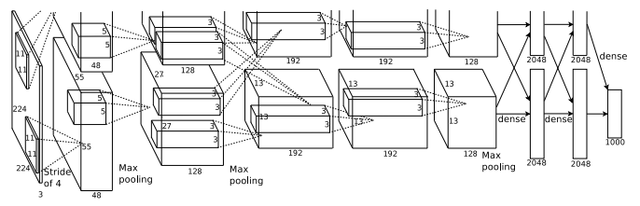

The network consisted of convolutional layers with kernels of size 11x11, 5x5 and 3x3. The architecture uses layers with strides, max poolings, dropouts, ReLU activation functions, and three dense layers at the very end. In their original work, the network was split into two streams, as seen in the figure above. That was because GPU constraints, and hence, the authors needed to train it on two separate GPUs. We found a great implementation in [Rizwan's blog](https://engmrk.com/alexnet-implementation-using-keras/), where it presented an AlexNet model without the split concept.

In [ ]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),   # Conv1
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                   # Pool1

            nn.Conv2d(96, 256, kernel_size=11, stride=1, padding=0), # Conv2
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                   # Pool2

            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=0), # Conv3
            nn.ReLU(),

            nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=0), # Conv4
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=0), # Conv5
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                    # Pool5
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 4096),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        # CIFAR-10 stays 32x32 in the CPU loader; resize the complete batch on GPU.
        if x.shape[-2:] != (224, 224):
            x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        x = self.features(x)
        return self.classifier(x)


In [ ]:
torchinfo.summary(AlexNet(10), input_size=(1, 3, 224, 224))

The original AlexNet expects an ImageNet-sized input. CIFAR-10 remains at $32\times32$ in the loader, and the model resizes the complete batch to $224\times224$ on the GPU. We use the balanced teaching subset and a three-epoch budget so the demonstration produces regular progress output and finishes within a practical tutorial session.


In [ ]:
set_seed(42)

model = AlexNet(num_classes=10).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print(f"AlexNet parameters: {sum(p.numel() for p in model.parameters()):,} | device: {DEVICE}", flush=True)
train_classifier(3, train_loader, model, criterion, optimizer)
evaluate_classifier(test_loader, model, criterion)


As it could be observed, training this kind of architectures in big datasets is time-consuming. We might need to train for several hours to start getting state-of-the-art results. That is why Pytorch saves us time and offers us several pre-trained models on the ImageNet dataset.

Those models can be used directly for image prediction, image classification, feature extraction, or fine-tuning, among others, without the need of spending long hours of training. Isn't that great!?

Even if the task or the dataset is different, using the pre-trained weights as initialisation for the training process provides usually faster convergence (and sometimes better results) than random initialisation.

# Loading Pre-trained Models in Pytorch

As mentioned, Pytorch contains many models that have been trained in the ImageNet dataset. Those models were originally released to participate in the ILSVRC competition. However, now they are available alongside their pre-trained weights and used in multiple different tasks. Using pre-trained weights has become a common practice to initialise networks. You can learn more about it [here](https://docs.pytorch.org/vision/main/models.html).

We will show how to initialise different models and load their pre-trained weights in ImageNet. Afterwards, we will show how to modify the last layer to classify only the ten classes we have in CIFAR10.

## VGGNet

VGGNet is an architecture presented by Simonyan and Zisserman in 2014. VGGNet is similar to previous AlexNet network, however, it only contains 3x3 convolutional kernels and many more filters. It has become really popular since researchers have found that it can be used to extract powerful feature representations from an image. Therefore, extracted features have proven that they are useful for many other computer vision domains and not only image classification. For instance, they can be used in feature representation, style transfer, or image captioning. You can check the [Oxford VGG paper](https://arxiv.org/pdf/1409.1556.pdf) for further details.

Next image shows the standard VGG architecture ([source](https://www.cs.toronto.edu/~frossard/post/vgg16/)):

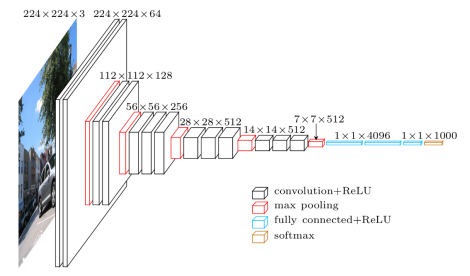

The training time of the architecture is massive since it has more than 130 million parameters. Thankfully, we can find it already pre-trained in Pytorch. In the original work, authors proposed two versions of VGG; VGG16, and VGG19. Pytorch provides the both proposed versions, where the difference lies in the number of layers within the network.


In [ ]:
torchinfo.summary(models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1), input_size=(1, 3, 224, 224))

The argument `weights` indicates to Pytorch whether we need to use the pre-trained weights from ImageNet.

If we want to use the original VGG model in CIFAR10 classification, we need to change some things. The first thing to modify is the last fully connected layer. In the original VGG, the last layer is designed to classify among the 1,000 classes provided in ImageNet. In CIFAR10, as we already know, we only have ten classes. Therefore, we switch the last dense layer in the model to be able to perform classification on CIFAR10. Moreover, a common practise when using pre-trained networks is to freeze the model and only train the new dense layer. This strategy is called Transfer Learning. You can read more about it and its difference to Fine-tuning in this great [blog](https://towardsdatascience.com/cnn-transfer-learning-fine-tuning-9f3e7c5806b2). Updating only the weights of the last layer provides several advantages; faster training time, good performance, and sometimes helps the networks to not overfit in small datasets.

In [ ]:
# Load pretrained VGG16 model
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all layers
for param in vgg16.parameters():
    param.requires_grad = False

# Replace classifier (fc layers)
vgg16.classifier = nn.Sequential(
    *list(vgg16.classifier.children())[:-1],  # keep up to fc2
    nn.Linear(4096, 10),                      # new output layer
)

# Check architecture
torchinfo.summary(vgg16, input_size=(1, 3, 224, 224))

We can confirm that the original dense layer is not there anymore, and instead, we have a new fully-connected layer with only ten activations. Also, as we have frozen the weights of the model, we see that the trainable parameters of the network belong to the new dense layer.

Let's now see how we can modify the VGG architecture to use any input image shape. First of all, if we want to use any other image resolution than 224x224, we need to only use the model `features`. This argument will remove all dense layers at the end of the architecture. Remember that the dense layer comes after a flatten layer (see the model summary above) and, therefore, the size of the flatten vector is fixed. If we modify the input image size, the flatten vector would inevitably change as well. Hence, we need to redefine all dense layers within the model every time we switch the input size.

In [ ]:
# Replace classifier with custom dense layers for smaller input (32x32)
# Note: We must recalculate the flattened feature size after pooling
# For 32x32 input, VGG16 reduces it to 1x1 feature map after conv/pooling

class CustomVGG(nn.Module):
    def __init__(self):
        super().__init__()
        # Load pretrained VGG16 model (without top classifier layers)
        vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        # Freeze all the convolutional layers
        for param in vgg16.features.parameters():
            param.requires_grad = False

        self.features = vgg16.features  # only the convolutional part
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(512, 4096),  # 512 from final feature map size: (512, 1, 1)
            nn.ReLU(),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Linear(4096, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

In [ ]:
torchinfo.summary(model = CustomVGG(), input_size=(1, 3, 32, 32))

We have added the same number of dense layers as in original VGG. We are ready to train the newly added layers as we did in the previous step. But first, we must prepare a new dataset to match the required input size.

In [ ]:
# Transform to normalise CIFAR-10 images (no resizing)
norm_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
])

# Load CIFAR-10 train and test datasets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=norm_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=norm_transform)

# Build data loaders
# Run:ai workspaces have limited shared memory; use the main process to avoid /dev/shm exhaustion.
train_loader = DataLoader(trainset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(testset, batch_size=32, shuffle=False, num_workers=0)

In [ ]:
set_seed(42)

model = CustomVGG()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_classifier(3, train_loader, model, criterion, optimizer)
evaluate_classifier(test_loader, model, criterion)

## GoogLeNet / Inception v1

Google presented [GoogLeNet](https://arxiv.org/pdf/1409.4842.pdf) in 2014, the same year that VGGNet was introduced.  GoogLeNet won the ImageNet competition achieving a top-5 error rate of 6.67%, almost betting the human error rate (5%).

GoogLeNet introduced many ideas that helped the development of current state-of-the-art architectures. Instead of stacking more and more CNN layers, GoogLeNet introduced what was called inception modules:

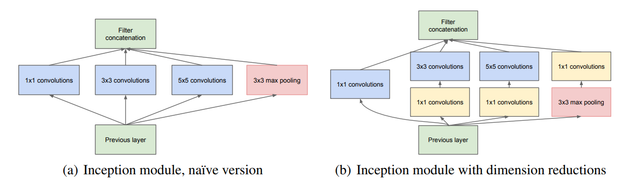

Those modules apply convolutions with 3 different sizes of kernels (1x1, 3x3 and 5x5) at the same level. The idea behind those modules is based on the premise that significant information can be presented in images at different scales. Therefore, by using a multi-scale approach, they are more likely to capture meaningful information. Moreover, they claimed that designing a wider architecture, instead of a deeper, helps the gradients to navigate throughout the entire network.

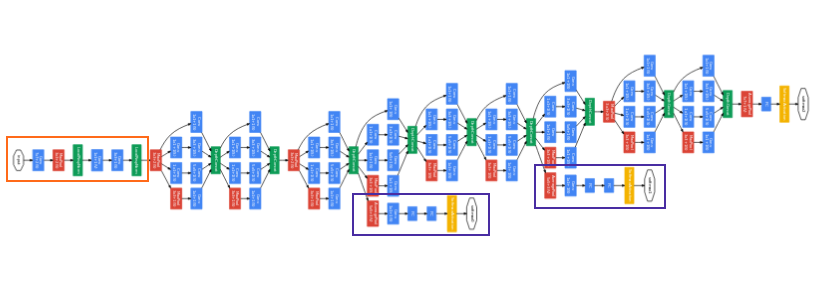

The architecture consisted of 9 inception modules stacked linearly, containing 22 deep CNN layers. However, in this network, the total number of parameters was reduced to 4 million! Authors also included two auxiliary classifiers in the middle part of the architecture to avoid the vanishing gradient problem.

Even though they won the image classification contest, original Inception v1 was a complex and heavily engineered architecture. Authors introduced many tricks to push its performance, both in terms of speed and accuracy. In the literature, we can find a constant evolution of the architecture which led to the creation of several improved versions. A list and explanation of all inception networks can be found in [this blog](https://towardsdatascience.com/a-simple-guide-to-the-versions-of-the-inception-network-7fc52b863202).  

In Pytorch, the Inception model v3 architecture is available, together with its pre-trained weights on ImageNet. It can be initialised as follows:

In [ ]:
torchinfo.summary(models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True), input_size=(1, 3, 299, 299))

Every network has its requirements. For instance, Inception v3 needs a minimum image input size of 75x75 due to its design. We can use the lambda function defined previously in the tutorial and see how the network performs in CIFAR10.

In [ ]:
# Create the complete model with preprocessing and new classification head
class CustomInceptionV3(nn.Module):
    def __init__(self):
        super().__init__()
        # Input preprocessing (resizing)
        self.transform = transforms.Compose([
            transforms.Resize((299, 299), interpolation=transforms.InterpolationMode.BILINEAR)
        ])

        # Create InceptionV3 model with pretrained weights
        base_model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        # Freeze all the layers
        for param in base_model.parameters():
            param.requires_grad = False

        # Use the feature extraction part of InceptionV3
        # We need to find the layer before the fully connected layers
        # Examining the structure, the 'Mixed_7c' module seems to be the last feature extractor
        self.features = nn.Sequential(
            base_model.Conv2d_1a_3x3,
            base_model.Conv2d_2a_3x3,
            base_model.Conv2d_2b_3x3,
            nn.MaxPool2d(kernel_size=3, stride=2),
            base_model.Conv2d_3b_1x1,
            base_model.Conv2d_4a_3x3,
            nn.MaxPool2d(kernel_size=3, stride=2),
            base_model.Mixed_5b,
            base_model.Mixed_5c,
            base_model.Mixed_5d,
            base_model.Mixed_6a,
            base_model.Mixed_6b,
            base_model.Mixed_6c,
            base_model.Mixed_6d,
            base_model.Mixed_6e,
            base_model.Mixed_7a,
            base_model.Mixed_7b,
            base_model.Mixed_7c,
        )

        # Classification head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(2048, 10) # 2048 is the output channels of Mixed_7c

    def forward(self, x):
        # Apply transformations
        x = self.transform(x)
        # Extract features
        x = self.features(x)
        # Apply pooling and classification
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [ ]:
torchinfo.summary(CustomInceptionV3(), input_size=(1, 3, 224, 224))

Let's train Inception v3:

In [ ]:
set_seed(42)

model = CustomInceptionV3()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_classifier(3, train_loader, model, criterion, optimizer)
evaluate_classifier(test_loader, model, criterion)

## ResNet

In 2015, the winner of the ImageNet challenge was the Residual Neural Network ([ResNet](https://arxiv.org/pdf/1512.03385.pdf)) architecture. Similar to Inception, ResNet is built by micro-architectures modules, called residual blocks. Those blocks introduced skip connections, which allowed to train huge architectures (152 layers) while still having lower complexity than VGGNet. Thus, residual connections allowed authors to design deeper architectures since the gradient could backpropagate easier through the skip connections. Next image is from [Das' blog](https://medium.com/@sidereal/cnns-architectures-lenet-alexnet-vgg-googlenet-resnet-and-more-666091488df5) and shows ResNet architecture with its skip connections:

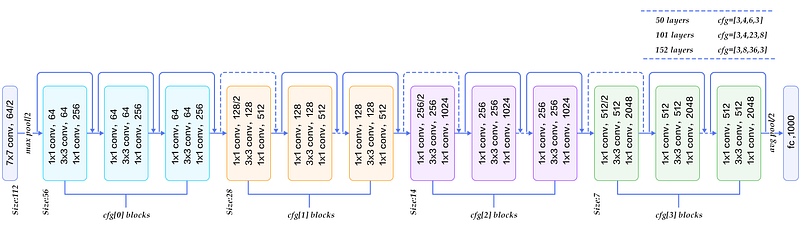

ResNet has various verions (e.g., ResNet50, ResNet101, ResNet152) with the main difference lying in the number of layers used.

In [ ]:
# Custom ResNet50 model for CIFAR-10
class CustomResNet50(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Load pretrained ResNet50
        base_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Freeze all layers
        for param in base_model.parameters():
            param.requires_grad = False

        # Remove the original classifier (fc)
        self.features = nn.Sequential(*list(base_model.children())[:-2])  # Up to last conv layer
        self.pool = nn.AdaptiveAvgPool2d((1, 1))  # Global Average Pooling
        self.classifier = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.features(x)          # ResNet backbone
        x = self.pool(x)              # Global Average Pooling
        x = torch.flatten(x, 1)       # Flatten
        x = self.classifier(x)        # Final Dense layer
        return x

In [ ]:
torchinfo.summary(CustomResNet50(num_classes=10), input_size=(1, 3, 32, 32))

Let's check the performance:

In [ ]:
set_seed(42)

model = CustomResNet50(num_classes=10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

train_classifier(3, train_loader, model, criterion, optimizer)
evaluate_classifier(test_loader, model, criterion)

Note that all previous networks may need a different number of epochs until they converge. Even though we use pre-trained weights, fully training a model can be quite time-consuming.

## DenseNet

DenseNet, short for Densely Connected Convolutional Network, was introduced in 2017 in the paper [Densely Connected Convolutional Networks](https://arxiv.org/pdf/1608.06993). It brought a novel concept of dense connectivity, where each layer receives the feature maps of all preceding layers as input. This approach mitigates the vanishing gradient problem, improves feature propagation, and allows for fewer parameters than traditional architectures by reusing features.

Each dense block is followed by a transition layer that performs downsampling. Compared to ResNet's additive skip connections, DenseNet concatenates the outputs of previous layers, which encourages feature reuse and compact models.

The diagram below (from the original paper) illustrates how DenseNet differs in connectivity:

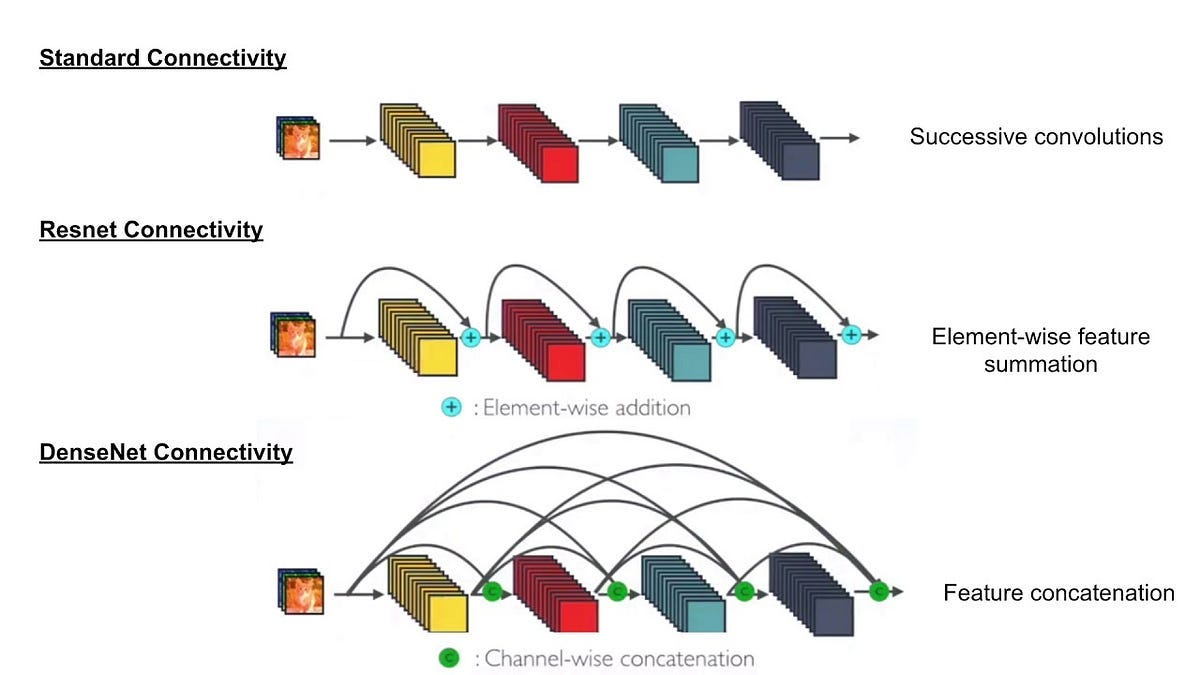


PyTorch offers pre-trained DenseNet models. The most popular variant is DenseNet-121, which has 121 layers, but deeper variants like DenseNet-169, 201, and 264 also exist.



## MobileNet

[MobileNet](https://arxiv.org/abs/1704.04861) was introduced in 2017 for efficient image classification on phones, embedded devices and other systems with limited memory, power or latency budgets. In contrast with AlexNet's wide standard convolutions and large fully connected classifier, MobileNetV1 reduces computation using **depthwise separable convolutions**.

The original ImageNet MobileNetV1 architecture is shown below. Unlike a simple flow chart, the figure shows the changing feature-map dimensions, convolution kernels, depthwise (DW) layers, pointwise (PW) layers, global average pooling and the final classifier.

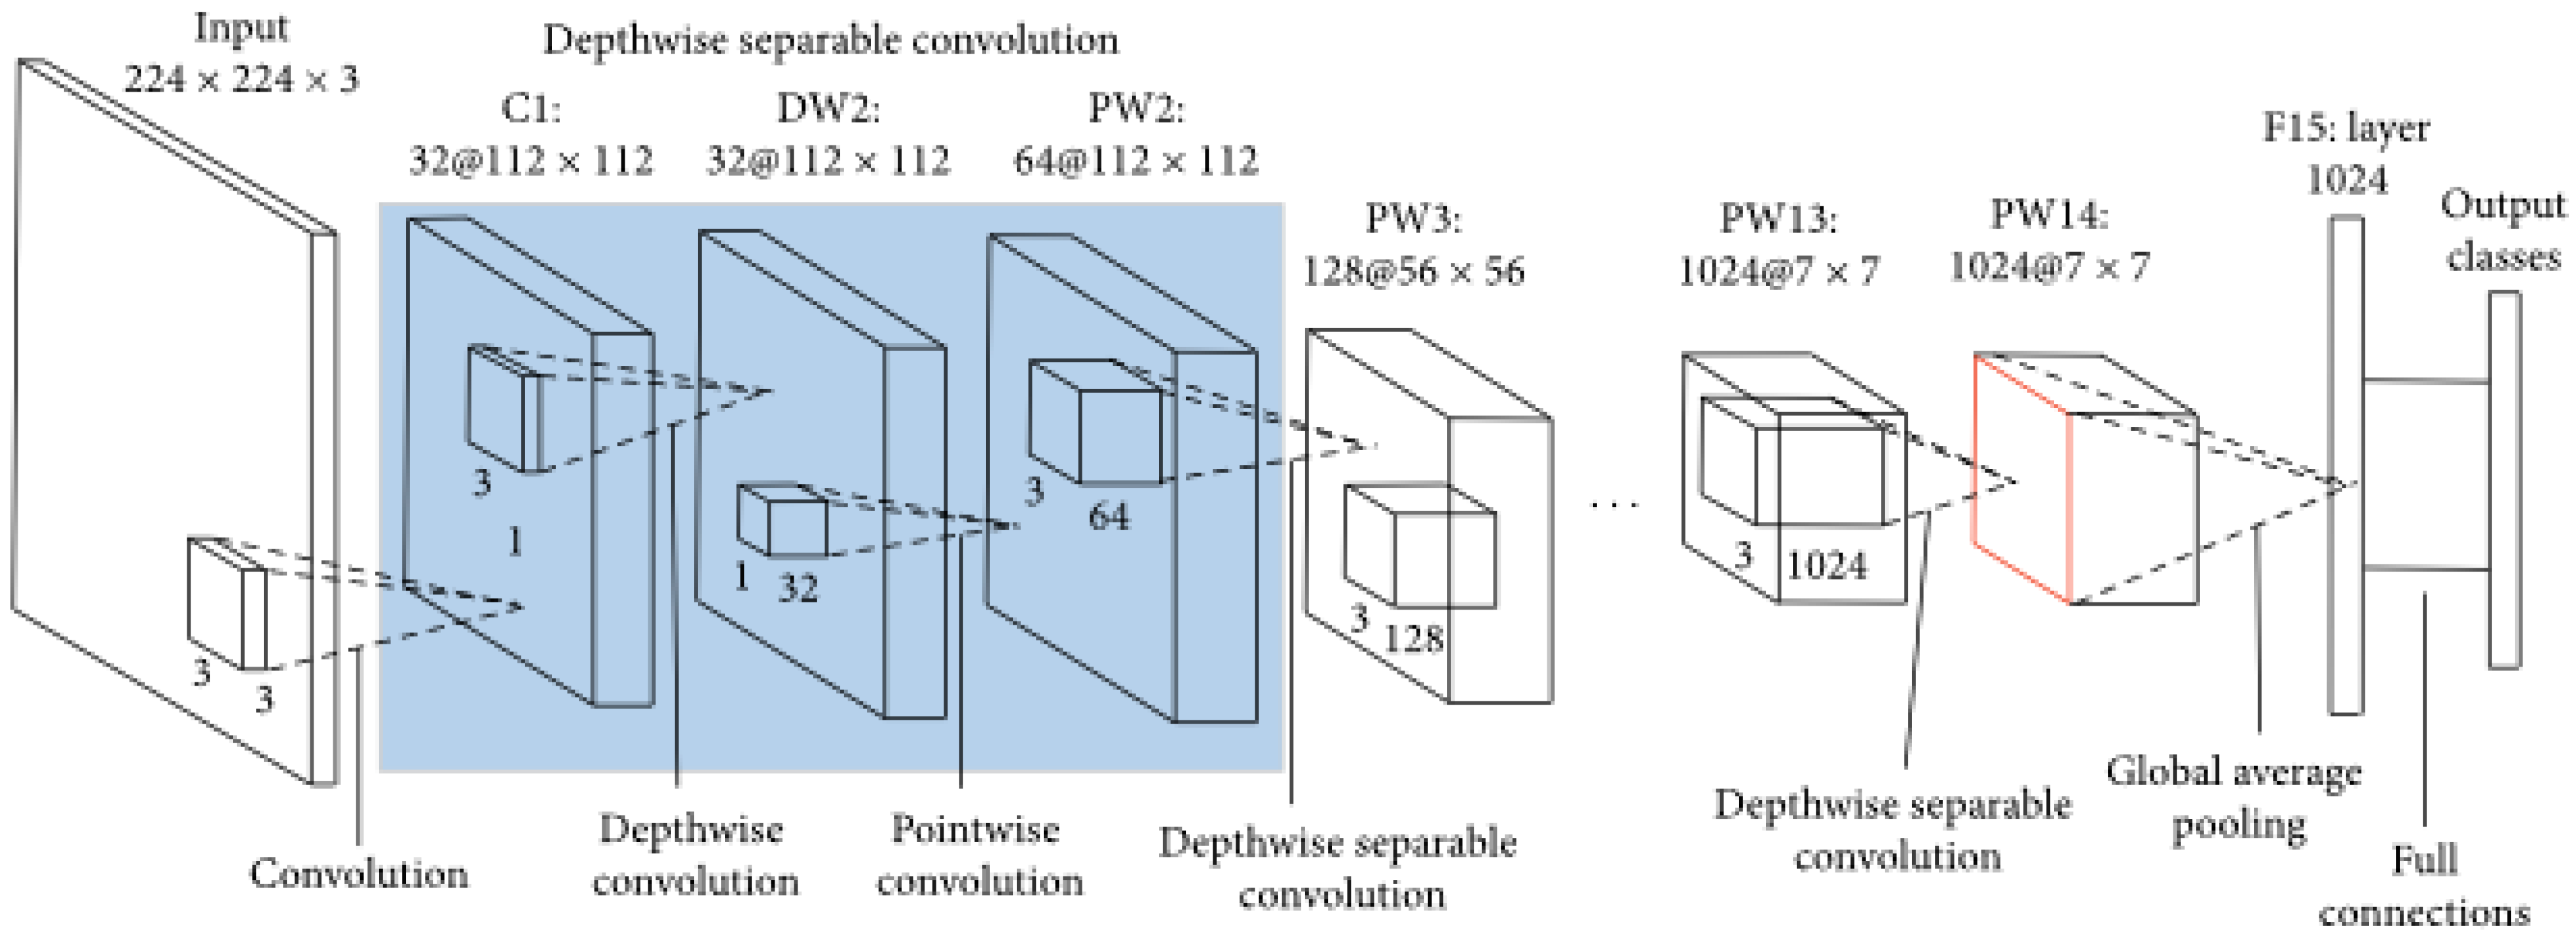

*Figure source: Yuldashev et al., [Parking Lot Occupancy Detection with Improved MobileNetV3](https://doi.org/10.3390/s23177642), Figure 1, licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*

The published figure uses the original $224 \times 224$ ImageNet input. The teaching implementation below preserves the MobileNetV1 body but adapts it to CIFAR-10: it uses $32 \times 32$ inputs, changes the first stride from 2 to 1, and replaces the 1000-class output with a 10-class classifier.

A standard convolution with a square kernel of width $K$, $M$ input channels and $N$ output channels contains:

$$
P_{\mathrm{standard}} = K^2MN
$$

MobileNet factorises this operation into a depthwise convolution and a pointwise convolution:

$$
P_{\mathrm{depthwise\ separable}} = K^2M + MN
$$

For a $3 \times 3$ layer with 32 input channels and 64 output channels:

$$
P_{\mathrm{standard}} = 3^2 \times 32 \times 64 = 18{,}432
$$

$$
P_{\mathrm{depthwise\ separable}} = 3^2 \times 32 + 32 \times 64 = 2{,}336
$$

Therefore, the factorised layer uses **87.3% fewer weights**. A depthwise convolution performs spatial filtering independently in each channel; the following $1 \times 1$ pointwise convolution mixes information across channels.

The two operations are illustrated as actual feature maps and filters below:

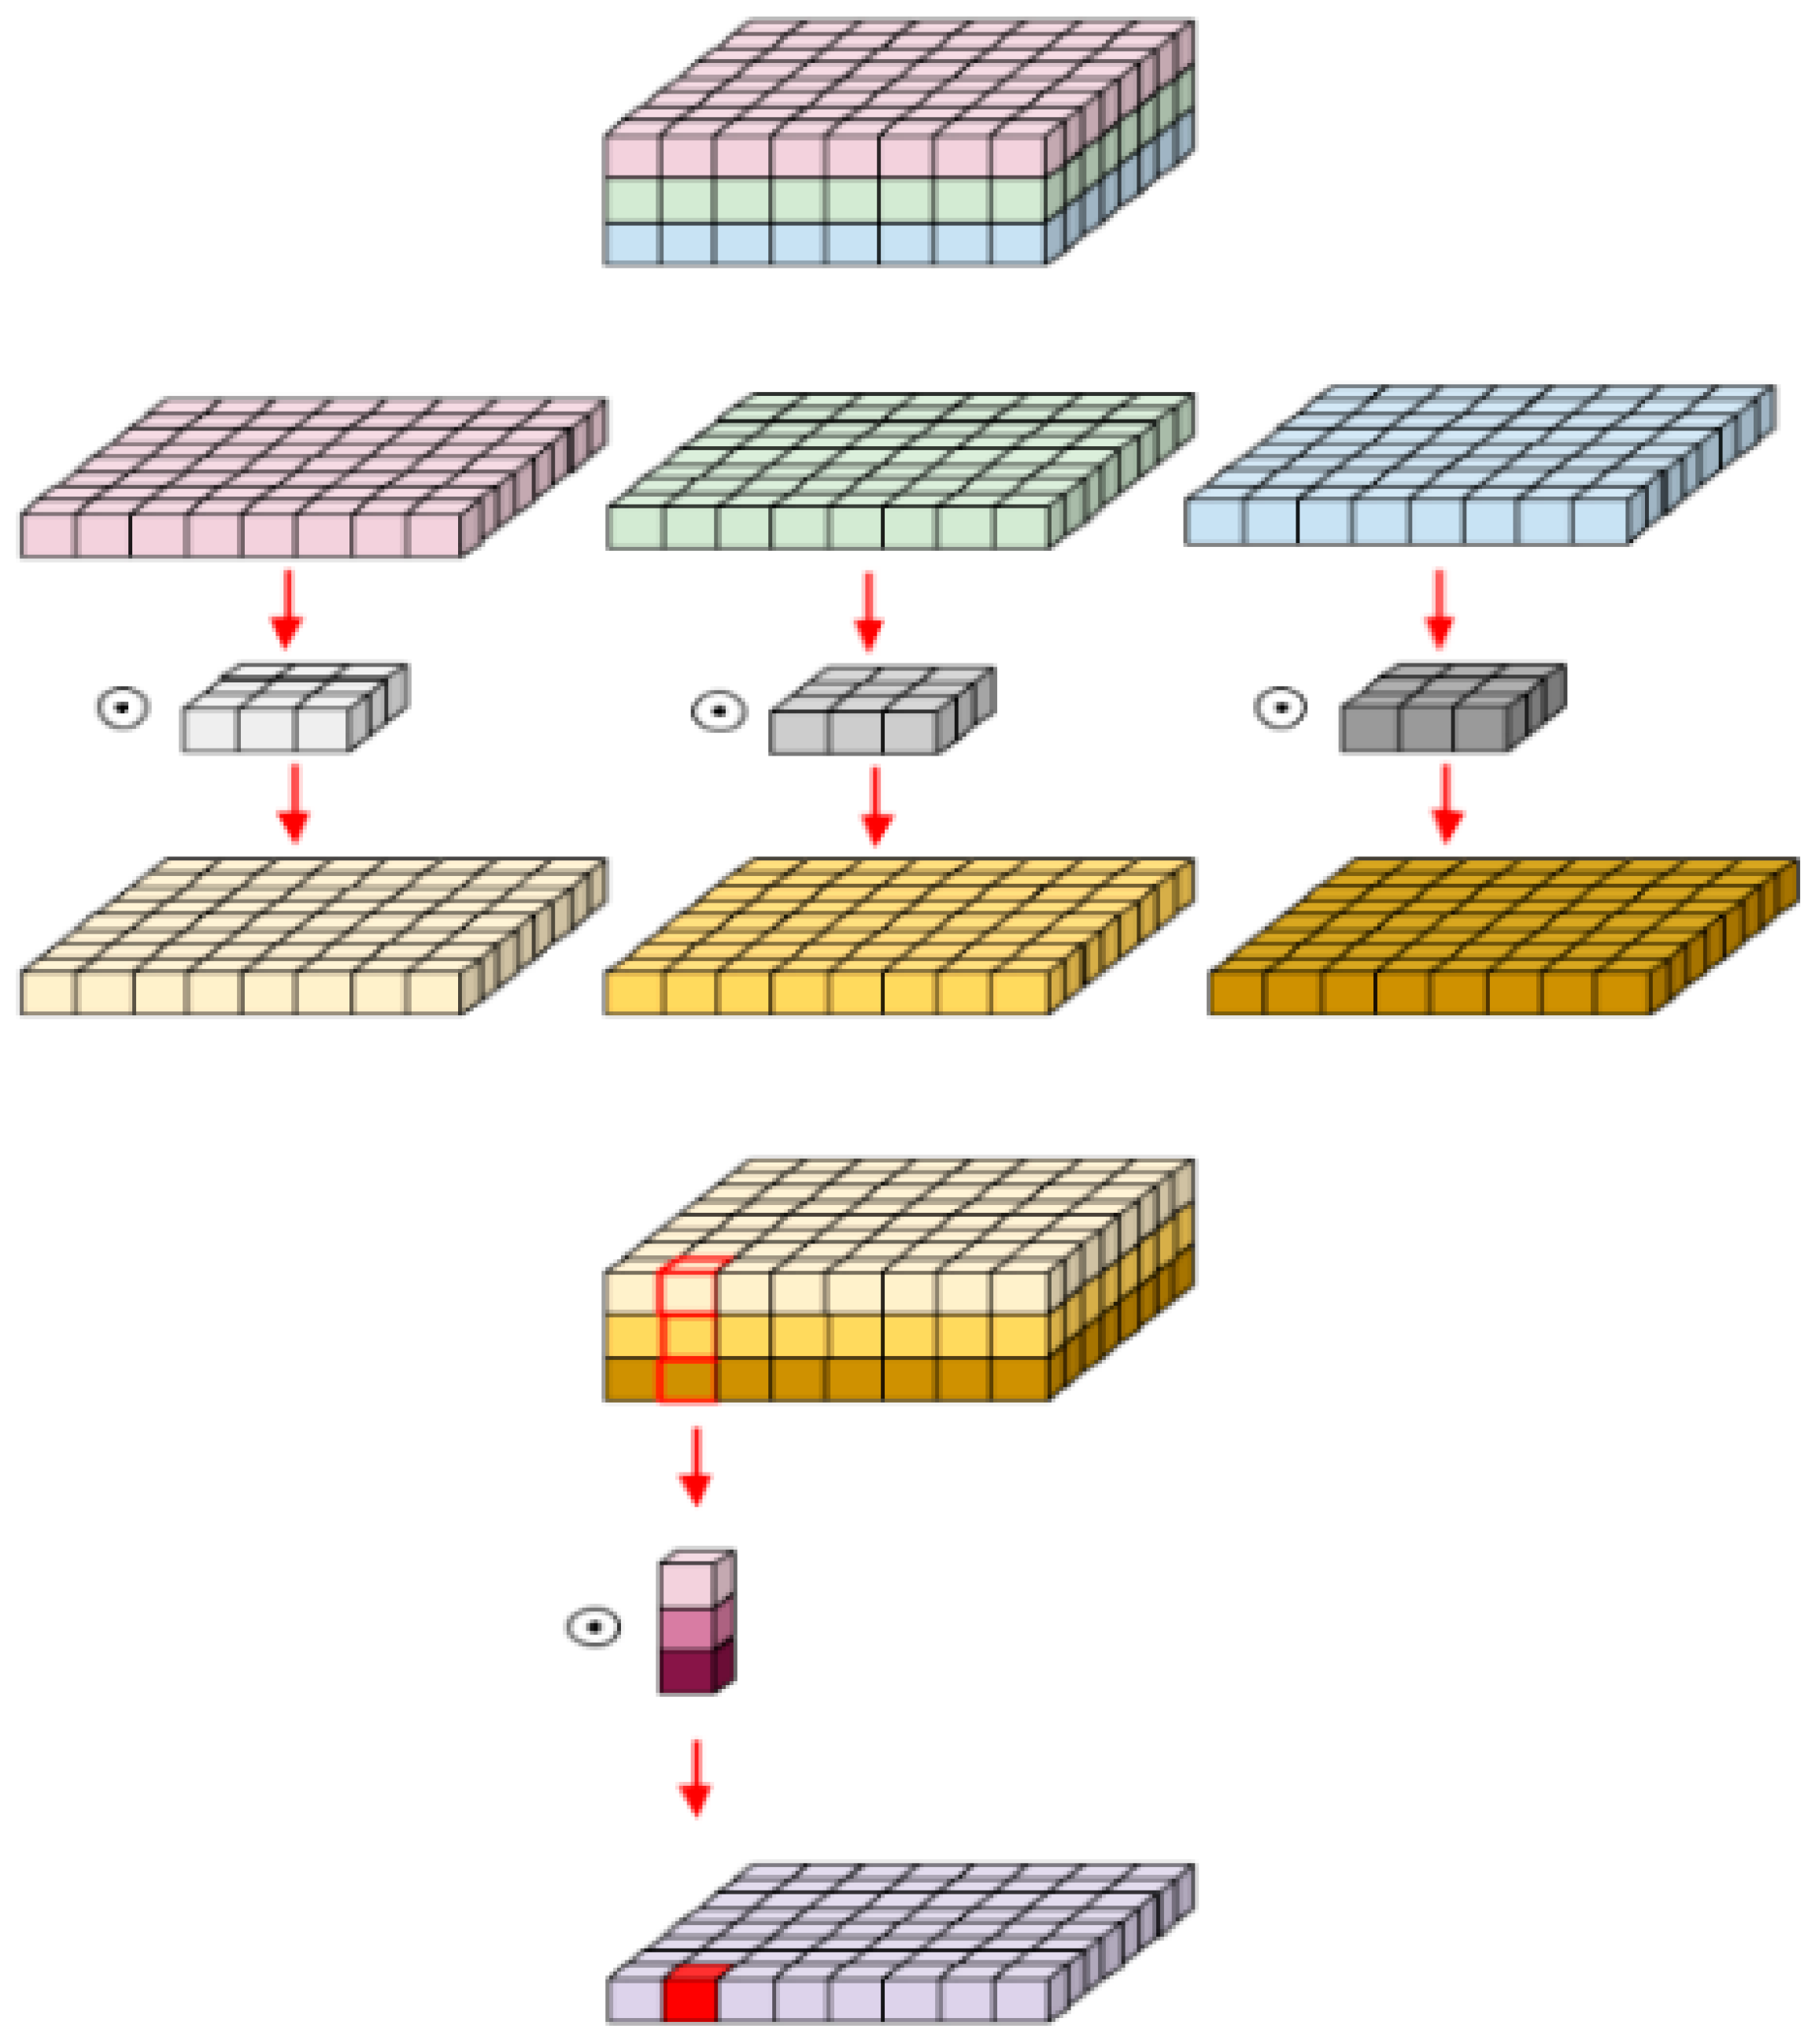

*Figure source: Yuldashev et al., Figure 2, [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*

Our teaching implementation follows the MobileNetV1 design: a convolutional stem, thirteen depthwise-separable blocks, adaptive global average pooling and one linear classifier. Later versions, including MobileNetV2 and MobileNetV3, introduce inverted residual blocks, linear bottlenecks and architecture-search improvements.


In [ ]:
def convolution_parameter_count(kernel_size, in_channels, out_channels):
    standard = kernel_size**2 * in_channels * out_channels
    depthwise_separable = kernel_size**2 * in_channels + in_channels * out_channels
    reduction = 100.0 * (1.0 - depthwise_separable / standard)
    return standard, depthwise_separable, reduction


standard_params, mobile_params, reduction = convolution_parameter_count(3, 32, 64)
print(f"Standard 3x3 convolution:       {standard_params:,} weights")
print(f"Depthwise separable convolution: {mobile_params:,} weights")
print(f"Reduction: {reduction:.1f}%")


In [ ]:
class DepthwiseSeparableConv(nn.Module):
    # MobileNetV1 block: depthwise spatial filtering followed by pointwise mixing.

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.depthwise = nn.Sequential(
            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                groups=in_channels,
                bias=False,
            ),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
        )
        self.pointwise = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.pointwise(self.depthwise(x))


class MobileNetV1(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # The original ImageNet model uses stride 2 here. We use stride 1 so that
        # CIFAR-10's 32x32 spatial information is not reduced too aggressively.
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        configuration = [
            (64, 1),
            (128, 2), (128, 1),
            (256, 2), (256, 1),
            (512, 2),
            (512, 1), (512, 1), (512, 1), (512, 1), (512, 1),
            (1024, 2), (1024, 1),
        ]

        layers = []
        in_channels = 32
        for out_channels, stride in configuration:
            layers.append(DepthwiseSeparableConv(in_channels, out_channels, stride))
            in_channels = out_channels

        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


In [ ]:
mobilenet = MobileNetV1(num_classes=10)
torchinfo.summary(mobilenet, input_size=(1, 3, 32, 32))

alexnet_parameters = sum(parameter.numel() for parameter in AlexNet(10).parameters())
mobilenet_parameters = sum(parameter.numel() for parameter in mobilenet.parameters())
print(f"AlexNet parameters:    {alexnet_parameters:,}")
print(f"MobileNet parameters:  {mobilenet_parameters:,}")
print(f"MobileNet uses {100.0 * mobilenet_parameters / alexnet_parameters:.1f}% of the AlexNet parameter count.")


Unlike AlexNet, this MobileNet implementation can process CIFAR-10 at its native $32\times32$ resolution. Adaptive average pooling also removes the need for a large fixed-size fully connected classifier. This makes the example substantially faster and highlights that model efficiency depends on both the convolutional block and the classifier design.

The following short run is a teaching demonstration, not a benchmark. It uses exactly the same balanced CIFAR-10 subset and three-epoch budget as the AlexNet example so that parameter count, runtime behaviour and early accuracy can be compared fairly.


In [ ]:
set_seed(42)

model = MobileNetV1(num_classes=10).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(f"MobileNet parameters: {sum(p.numel() for p in model.parameters()):,} | device: {DEVICE}", flush=True)
train_classifier(3, train_loader, model, criterion, optimizer)
evaluate_classifier(test_loader, model, criterion)


### AlexNet and MobileNet: what should we learn?

* **AlexNet** increases representational capacity with wide standard convolutions and large dense layers. It was historically important, but it is expensive by modern deployment standards.
* **MobileNet** reduces convolutional cost through depthwise separable operations and replaces large dense layers with global average pooling and a small classifier.
* Fewer parameters do not automatically guarantee higher accuracy. Architecture, optimisation, training duration, input resolution and transfer learning all affect the result.
* A fair efficiency comparison should consider accuracy together with parameter count, latency and memory use, rather than accuracy alone.


In [ ]:
# Custom DenseNet121 for CIFAR-10
class CustomDenseNet121(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Load pretrained DenseNet121
        base_model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

        # Freeze feature extractor layers
        for param in base_model.features.parameters():
            param.requires_grad = False

        # Replace the classifier
        self.features = base_model.features
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
torchinfo.summary(CustomDenseNet121(num_classes=10), input_size=(1, 3, 32, 32))

In [ ]:
set_seed(42)

model = CustomDenseNet121(num_classes=10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

train_classifier(3, train_loader, model, criterion, optimizer)
evaluate_classifier(test_loader, model, criterion)

## ConvNeXt

[ConvNeXt](https://arxiv.org/abs/2201.03545) was introduced in 2022 by Liu et al. It is a pure convolutional network that modernises the ResNet backbone by adopting design principles from Vision Transformers (ViT). At the time, ViTs had begun to match or surpass CNNs on ImageNet, raising the question of whether convolutions were fundamentally limited. ConvNeXt showed that a properly modernised CNN can compete with ViTs in accuracy and scalability while retaining the efficiency of standard convolutions.

Starting from a ResNet-50 backbone, the authors gradually applied a series of changes inspired by ViT/Swin Transformer designs. The figure below (from the original paper) shows how the block evolves from a ResNeXt bottleneck (a) to an inverted bottleneck (b) and finally to the ConvNeXt block (c), where the large depthwise convolution is moved to the position of self-attention in a Transformer:

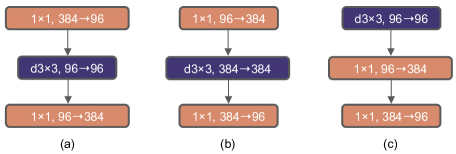

*Figure source: Liu et al., [A ConvNet for the 2020s](https://arxiv.org/abs/2201.03545), Figure 3, licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*

The key changes are:

* **Macro design:** change the stage compute ratio to be more ViT-like (fewer early-stage blocks, more in the last stage); use a patchify stem (a $4\times4$ non-overlapping convolution) instead of ResNet's $7\times7$ stride-2 stem.
* **Inverted bottleneck:** the channel dimension expands inside the block (like MobileNetV2) so spatial mixing (depthwise conv) and channel mixing (pointwise conv) are separated.
* **Large depthwise convolution:** replace the standard $3\times3$ bottleneck convolutions with large $7\times7$ depthwise convolutions, similar to the self-attention window in Swin. The depthwise layer is moved before the expansion, mirroring how MSA precedes the MLP in a Transformer block.

At the micro level, the ConvNeXt block also removes most activation and normalisation layers, replacing BatchNorm with LayerNorm and ReLU with GELU, as shown in the comparison below:

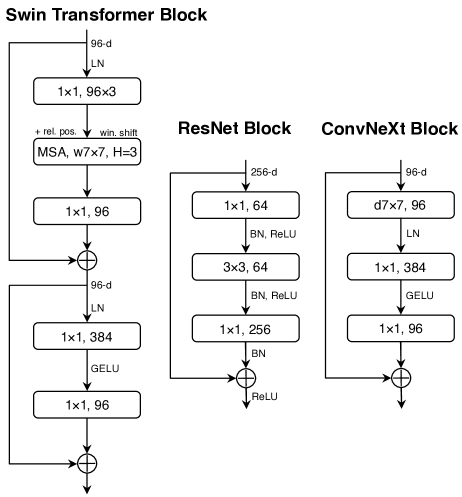

*Figure source: Liu et al., [A ConvNet for the 2020s](https://arxiv.org/abs/2201.03545), Figure 4, licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*

A learnable layer-scale parameter (inspired by ViT) is applied after the depthwise conv. The result is a block that looks remarkably like a Transformer block in structure, yet is built entirely from standard convolution operations.

Torchvision provides five ConvNeXt scales: **Tiny, Small, Base, Large** and **XLarge**. They differ in width (channel count) and depth (number of blocks per stage). In Task 2 you will compare the first four scales on Tiny-ImageNet using head-only fine-tuning (linear probing).


## Architecture Summary and Timeline

The table below summarises every architecture covered in this tutorial and traces how CNN design evolved over a decade. Parameter counts and ImageNet top-1 accuracies are approximate, drawn from the original publications or torchvision documentation. UNet is included for completeness, but it was designed for dense prediction rather than ImageNet classification, so those columns are marked N/A.

| Year | Architecture | Key Innovation | Parameters | ImageNet Top-1 | Covered As |
|:----:|:-------------|:---------------|:----------:|:---------------:|:-----------|
| 2012 | AlexNet | ReLU activation, GPU training, dropout, data augmentation | ~60M | 57.1% | From scratch |
| 2014 | VGGNet | Stacked $3{\times}3$ convolutions; deeper and narrower filters | ~138M | 71.5% | Pretrained |
| 2014 | GoogLeNet (Inception v1) | Parallel multi-scale paths via inception modules | ~7M | 69.8% | Pretrained |
| 2015 | ResNet | Skip (residual) connections enabling 152-layer depth | ~25M | 76.0% | Pretrained |
| 2015 | UNet | Symmetric encoder-decoder with skip connections for dense prediction | N/A | N/A | Denoising demo |
| 2017 | DenseNet | Dense connectivity: each layer receives all preceding feature maps | ~8M | 76.2% | Pretrained |
| 2017 | MobileNet | Depthwise separable convolutions for mobile efficiency | ~4M | 70.6% | From scratch |
| 2019 | EfficientNet | Compound scaling of depth, width, and resolution together | ~5M $-$ 66M | 78.8 $-$ 88.4% | Mentioned |
| 2020 | Vision Transformer (ViT) | Patch embeddings + self-attention replacing convolutions | ~6M $-$ 304M | 79.0 $-$ 88.6% | Mentioned |
| 2021 | Swin Transformer | Hierarchical features via shifted-window attention | ~28M $-$ 197M | 80.8 $-$ 87.3% | Mentioned |
| 2022 | ConvNeXt | Modernised ResNet adopting ViT design principles (LayerNorm, GELU, $7{\times}7$ depthwise, inverted bottleneck) | ~28M $-$ 198M | 82.1 $-$ 87.8% | Linear probing |

### Recurring themes

Looking across a decade of architecture design, several patterns emerge:

* **Depth.** AlexNet had 8 trainable layers; ResNet reached 152. Skip connections were the key enabler — without them, very deep networks suffered from vanishing gradients and degradation.
* **Efficiency.** VGG's 138M parameters were reduced to MobileNet's 4M by factorising standard convolutions into depthwise and pointwise operations. EfficientNet later showed that depth, width, and resolution should be scaled *together* rather than independently.
* **Feature reuse.** ResNet *adds* previous features via skip connections; DenseNet *concatenates* them, encouraging explicit feature reuse and producing more compact models.
* **Cross-pollination with Transformers.** After ViT (2020) challenged CNN dominance, ConvNeXt (2022) showed that a pure CNN modernised with Transformer-style design choices (LayerNorm, GELU, large kernels, inverted bottleneck, layer scale) can match or exceed hierarchical Transformer accuracy while retaining convolutional efficiency.

## More Architectures

Beyond the architectures covered above, several important families have shaped modern computer vision. PyTorch offers pretrained implementations of most of them — see the [documentation](https://docs.pytorch.org/vision/main/models.html) for a complete list with accuracies, parameter counts, and depths.

* **EfficientNet (2019)** — introduced [compound scaling](https://arxiv.org/abs/1905.11946): instead of scaling only depth, width, *or* resolution, all three are scaled together following a fixed ratio. This gave a family of models (B0–B7) that dominated the accuracy-per-FLOP frontier for several years.

* **Vision Transformer / ViT (2020)** — the first [pure-Transformer image classifier](https://arxiv.org/abs/2010.11929) to rival CNNs on ImageNet. An image is split into fixed-size patches, each patch is linearly embedded into a token, and a standard Transformer encoder processes the sequence. ViT lacks the inductive bias of convolutions (locality, translation invariance), so it benefits from large-scale pre-training.

* **Swin Transformer (2021)** — a [hierarchical Transformer](https://arxiv.org/abs/2103.14030) that computes self-attention in local shifted windows, giving linear complexity with respect to image size. Its multi-stage feature hierarchy makes it suitable for dense prediction tasks (detection, segmentation) where ViT is less natural.

* **ConvNeXt (2022)** — discussed in the previous section; a modernised pure-CNN that matches Transformer accuracy and scaling behaviour.

The field continues to move: hybrid CNN-Transformer models, MLP-based architectures, and foundation models pre-trained on billions of images are all active research directions. The key lesson from this progression is that architecture design involves trade-offs between accuracy, efficiency, data requirements, and inductive bias — no single architecture dominates on every axis.

# CNNs for Other Tasks

Besides the success of CNNs in classification problems, CNNs have been used in many other domains. To name a few: image inpainting, facial recognition, semantic segmentation, image captioning, depth prediction, among many others. In this section, we are going to talk about two different problems in computer vision: image denoising and object detection/classification. We are aiming to provide examples of the wide applicability CNNs architectures have.


## Image Denoising with UNet

[UNet](https://arxiv.org/pdf/1505.04597.pdf) was presented in 2015 for biomedical image segmentation, but since then, it has been employed in countless different tasks, such as semantic segmentation, image colorisation, image stylisation... The UNet architectural idea is similar to a regular encoder-decoder layout but with skip connections. The first part of the network encodes the image and reduces it to a map of smaller size, forcing it to capture more global information. Then, the next part is in charge of decoding the image from that reduced feature map.

UNet uses a similar idea of the skip connections used in ResNets. In addition to helping to backpropagate the gradients, the authors used the skip connections to facilitate the flow of information between encoder and decoder. We will talk more about UNet in future tutorials, but for now, let's see how we can code an UNet model:

The U-Net architecture is shown below (from the original paper). The encoder (left side) progressively downsamples the input, while the decoder (right side) upsamples it back. Skip connections (grey arrows) concatenate encoder features with decoder features at matching resolutions, preserving fine spatial detail:

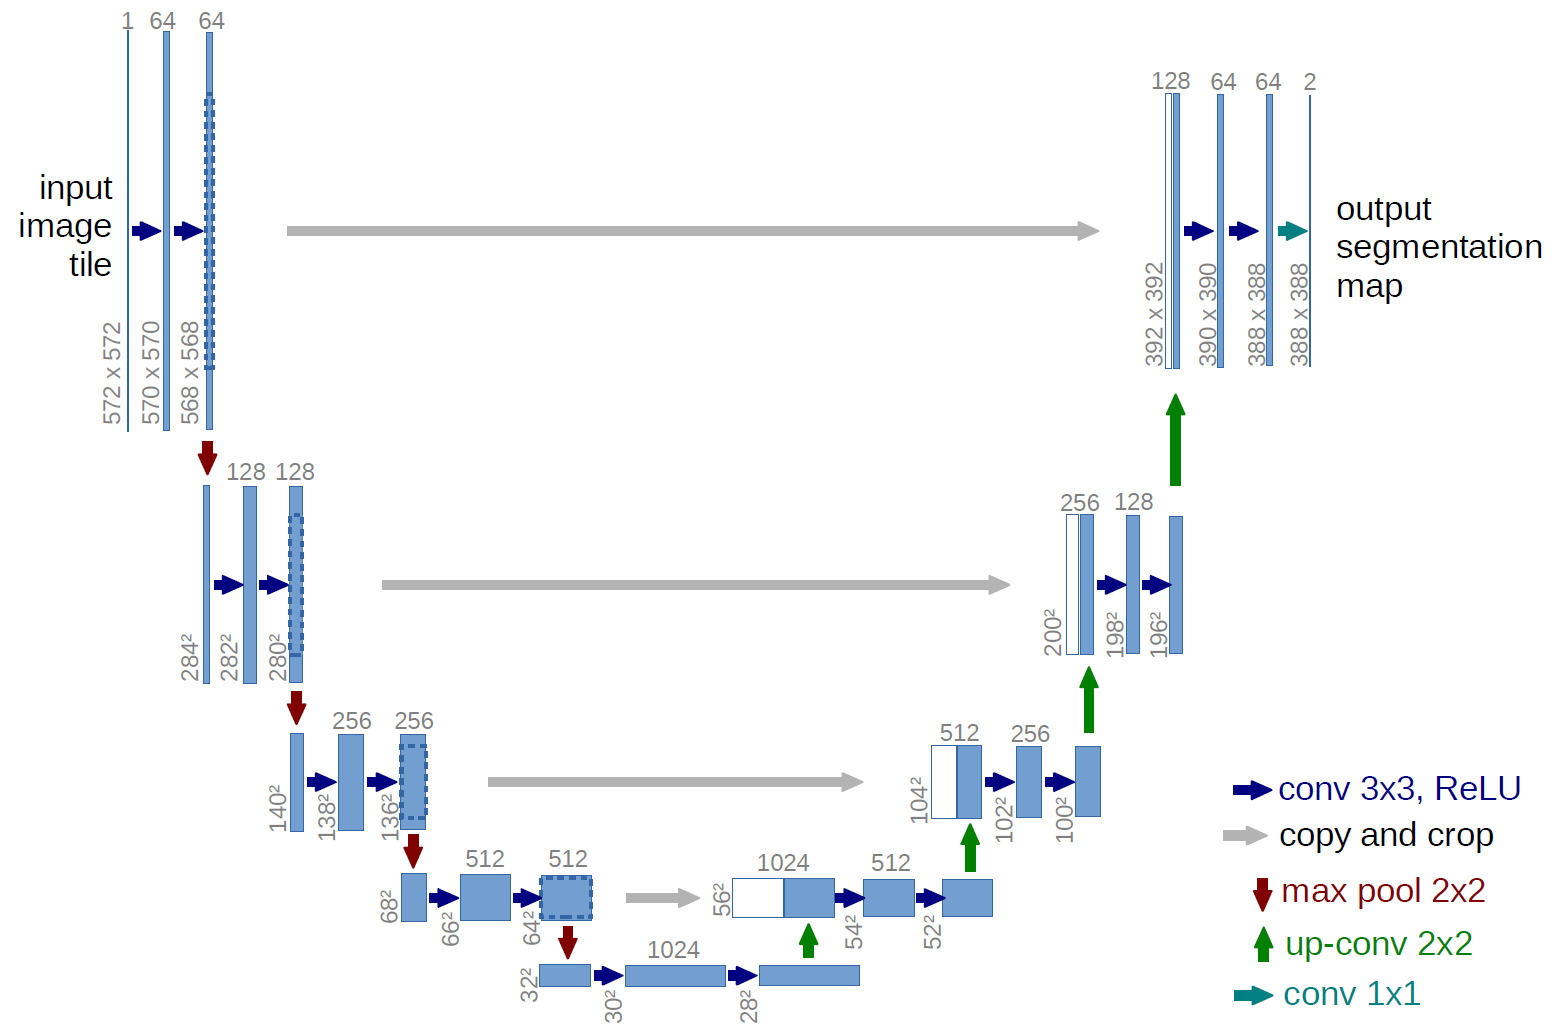


In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.conv1 = self.double_conv(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.conv3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.conv4 = self.double_conv(256, 512)
        self.drop4 = nn.Dropout(0.5)
        self.pool4 = nn.MaxPool2d(2)

        self.conv5 = self.double_conv(512, 1024)
        self.drop5 = nn.Dropout(0.5)

        # Decoder
        self.up6 = nn.Conv2d(1024, 512, kernel_size=3, padding=1)
        self.conv6 = self.double_conv(1024, 512)

        self.up7 = nn.Conv2d(512, 256, kernel_size=3, padding=1)
        self.conv7 = self.double_conv(512, 256)

        self.up8 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.conv8 = self.double_conv(256, 128)

        self.up9 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.conv9 = self.double_conv(128, 64)

        self.conv10 = nn.Conv2d(64, 3, kernel_size=3, padding=1)

    def double_conv(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        # Encoder
        c1 = self.conv1(x)
        p1 = self.pool1(c1)

        c2 = self.conv2(p1)
        p2 = self.pool2(c2)

        c3 = self.conv3(p2)
        p3 = self.pool3(c3)

        c4 = self.conv4(p3)
        d4 = self.drop4(c4)
        p4 = self.pool4(d4)

        c5 = self.conv5(p4)
        d5 = self.drop5(c5)

        # Decoder
        u6 = F.interpolate(d5, scale_factor=2, mode='bilinear', align_corners=True)
        u6 = self.up6(u6)
        u6 = torch.cat([u6, d4], dim=1)
        c6 = self.conv6(u6)

        u7 = F.interpolate(c6, scale_factor=2, mode='bilinear', align_corners=True)
        u7 = self.up7(u7)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.conv7(u7)

        u8 = F.interpolate(c7, scale_factor=2, mode='bilinear', align_corners=True)
        u8 = self.up8(u8)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.conv8(u8)

        u9 = F.interpolate(c8, scale_factor=2, mode='bilinear', align_corners=True)
        u9 = self.up9(u9)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.conv9(u9)

        output = self.conv10(c9)
        return output

In [ ]:
torchinfo.summary(UNet(), input_size=(1, 3, 32, 32))

Now, we are going to create a toy example of image denoising.

We have CIFAR10 images already loaded from previous experiments. We add some Gaussian noise (you can play with the scale of the noise) to those CIFAR10 images and then train the UNet to remove that added noise from the images. To do so, we train with the noisy image as input and the clean image as the target. We use the Mean Absolute Error as the loss function to optimise the architecture.

In [ ]:
# Get full dataset tensors from DataLoader (no labels used for autoencoder)
def extract_data(loader):
    all_images = []
    for imgs, _ in loader:
        all_images.append(imgs)
    return torch.cat(all_images, dim=0)

# Step 1: Extract CIFAR-10 images from original loaders
x_train_clean = extract_data(train_loader)
x_test_clean = extract_data(test_loader)

# Step 2: Add Gaussian noise
noise_std = 0.1
x_train_noisy = x_train_clean + noise_std * torch.randn_like(x_train_clean)
x_test_noisy = x_test_clean + noise_std * torch.randn_like(x_test_clean)

# Clip to valid range [0,1] if needed (optional, depending on transforms)
x_train_noisy = torch.clamp(x_train_noisy, 0., 1.)
x_test_noisy = torch.clamp(x_test_noisy, 0., 1.)

# Step 3: Wrap as TensorDatasets
train_dataset = TensorDataset(x_train_noisy, x_train_clean)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(x_test_noisy, x_test_clean)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
set_seed(42)

model = UNet()
criterion = nn.L1Loss()  # Mean Absolute Error
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_denoiser(5, train_loader, model, criterion, optimizer)
evaluate_denoiser(test_loader, model, criterion)

We can visualise the noisy image next to the output of the UNet. The output images are a little bit blurred, but the noise we added has definitely been reduced.

In [ ]:
def to_rgb(tensor):
    return torch.clamp(tensor, 0, 1).permute(1, 2, 0).cpu().numpy()

preds = []
model.eval()
with torch.no_grad():
    for x_noisy, _ in test_loader:
        x_noisy = x_noisy.to(DEVICE)
        output = model(x_noisy)
        preds.append(output.cpu())
pred = torch.cat(preds, dim=0)

N = 5
start_val = 0
fig, axes = plt.subplots(N, N, figsize=(10, 10))
for row in range(N):
    for col in range(N):
        idx = start_val + row + N*col
        noisy_img = to_rgb(x_test_noisy[idx])
        pred_img = to_rgb(pred[idx])
        im = np.concatenate((noisy_img, pred_img), axis=1)
        axes[row, col].imshow(im)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

plt.tight_layout()
plt.show()

## Object Detection with RetinaNet

We now will show an object detection example. Object detection differs from image classification in that in an image classification setting we give a label to the whole image, whereas in an object detection setting we give a label and bounding box per each of the classes that are present.

Top detector models include Faster R-CNN, YOLO (yes, it is called YOLO, standing for You Only Look Once; this is the unusual [resume](https://pjreddie.com/static/Redmon%20Resume.pdf) of the YOLO developer) or SSD (Single Shot Detector). Another detector is RetinaNet, which we use to give an example of object detection using the implementation based on [torchvision](https://github.com/pytorch/vision/).

In [ ]:
import torch
import torchvision
from torchvision.models.detection import retinanet_resnet50_fpn_v2, RetinaNet_ResNet50_FPN_V2_Weights
from torchvision.transforms import functional as F
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO
import time


SCORE_THRESHOLD = 0.45

# Load the model
weights = RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT
model = retinanet_resnet50_fpn_v2(weights=weights, box_score_thresh=SCORE_THRESHOLD)
model.eval()

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Get the COCO category names
COCO_INSTANCE_CATEGORY_NAMES = weights.meta["categories"]

def draw_boxes(image, boxes, labels, scores):
    """Draw bounding boxes on the image"""
    import cv2
    image = np.array(image)
    for box, label, score in zip(boxes, labels, scores):
        # Convert box coordinates to integers
        box = box.cpu().numpy().astype(int)

        # Generate random color for this class
        color = tuple(np.random.randint(0, 255, 3).tolist())

        # Draw box
        cv2.rectangle(image,
                     (box[0], box[1]),
                     (box[2], box[3]),
                     color,
                     2)

        # Draw label
        caption = f"{COCO_INSTANCE_CATEGORY_NAMES[label]} {score:.3f}"
        cv2.putText(image,
                   caption,
                   (box[0], box[1] - 10),
                   cv2.FONT_HERSHEY_SIMPLEX,
                   0.5,
                   color,
                   2)

    return image

def detection_url(url):
    # Download and load the image
    response = requests.get(url)
    image = Image.open(BytesIO(response.content)).convert('RGB')

    # Prepare image for the model
    transform = weights.transforms()
    img_tensor = transform(image).to(device)

    # Perform detection
    start = time.time()
    with torch.no_grad():
        prediction = model([img_tensor])
    print("processing time: ", time.time() - start)

    # Get predictions
    boxes = prediction[0]['boxes']
    scores = prediction[0]['scores']
    labels = prediction[0]['labels']

    # Filter predictions based on score
    mask = scores > SCORE_THRESHOLD
    boxes = boxes[mask]
    labels = labels[mask]
    scores = scores[mask]

    # Draw boxes on image
    result_image = draw_boxes(image, boxes, labels, scores)

    # Display result
    plt.figure(figsize=(15, 15))
    plt.axis('off')
    plt.imshow(result_image)
    plt.show()

Now, we can use any *URL* pointing to an image (some *URLs* may fail) as input, and we will get an output with the detections out of the 80 classes in Microsoft COCO. If you want to check the classes available, you can print the variable labels_to_names.

As an example, we, of course, input an image full of cats. The labels are a bit blurry, but you can see all of the cats have the correct bounding box around them.

In [ ]:
url = 'https://st3.depositphotos.com/1032808/12984/i/950/depositphotos_129842732-stock-photo-group-of-various-breeds-cats.jpg'
detection_url(url)

You can even try with images that contain different classes, and see how RetinaNet deals with multi-class images.

In [ ]:
url = 'https://cdn.mos.cms.futurecdn.net/hbKifQWBTcdhTEw8zsJWnF-1200-80.jpg'
detection_url(url)

# **Coursework**

## Task 1: Training Strategies on a Tiny-ImageNet Teaching Subset

Compare three VGG16 training strategies on the supplied fixed, class-balanced 20-class Tiny-ImageNet subset:

1. **From scratch:** initialise all weights randomly and train the complete network.
2. **Transfer learning:** load ImageNet-pretrained weights, freeze the feature extractor, and train only the new classifier.
3. **Fine-tuning:** load ImageNet-pretrained weights and train the complete network using the supplied lower learning rate.

The subset contains 100 training images, 25 validation images, and 50 test images per class. Use validation accuracy to select the best epoch and evaluate each selected model on the test set once.

The from-scratch experiment is intentionally a fixed-budget baseline. With only five epochs and 2,000 training images it may remain close to chance level; do not increase its budget. This low result is an expected part of the comparison and shows the effect of limited data and training when pretrained features are not available.


Record all metrics in `TASK1_RESULTS` and per-epoch training/validation accuracy in `TASK1_HISTORIES`.


In [ ]:
# Download Tiny-ImageNet once. Re-running this cell is safe.
from pathlib import Path
import subprocess

TINY_IMAGENET_ROOT = Path("IMagenet/tiny-imagenet-200")
if not TINY_IMAGENET_ROOT.exists():
    print("Downloading Tiny-ImageNet...", flush=True)
    subprocess.run(
        ["git", "clone", "--depth", "1", "https://github.com/seshuad/IMagenet"],
        check=True,
    )
else:
    print(f"Using existing dataset: {TINY_IMAGENET_ROOT.resolve()}")


In [ ]:
TEACHING_CLASS_IDS = tuple(range(20))
TRAIN_PER_CLASS = 100
VAL_PER_CLASS = 25
TEST_PER_CLASS = 50


def get_id_dictionary(root=TINY_IMAGENET_ROOT):
    with open(root / "wnids.txt") as handle:
        return {line.strip(): index for index, line in enumerate(handle) if line.strip()}


def read_image(path):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return image


def get_teaching_subset(class_ids=TEACHING_CLASS_IDS, root=TINY_IMAGENET_ROOT):
    id_dict = get_id_dictionary(root)
    selected_keys = [key for key, original_id in id_dict.items() if original_id in class_ids]
    if len(selected_keys) != len(class_ids):
        raise RuntimeError(f"Expected {len(class_ids)} classes, found {len(selected_keys)}")
    remapped_labels = {key: new_id for new_id, key in enumerate(selected_keys)}

    train_images, train_labels = [], []
    val_images, val_labels = [], []
    for key in selected_keys:
        image_dir = root / "train" / key / "images"
        for index in range(TRAIN_PER_CLASS):
            train_images.append(read_image(image_dir / f"{key}_{index}.JPEG"))
            train_labels.append(remapped_labels[key])
        for index in range(TRAIN_PER_CLASS, TRAIN_PER_CLASS + VAL_PER_CLASS):
            val_images.append(read_image(image_dir / f"{key}_{index}.JPEG"))
            val_labels.append(remapped_labels[key])

    test_images, test_labels = [], []
    per_class_count = {key: 0 for key in selected_keys}
    with open(root / "val" / "val_annotations.txt") as annotations:
        for line in annotations:
            image_name, key = line.split("\t")[:2]
            if key not in remapped_labels or per_class_count[key] >= TEST_PER_CLASS:
                continue
            test_images.append(read_image(root / "val" / "images" / image_name))
            test_labels.append(remapped_labels[key])
            per_class_count[key] += 1

    incomplete = {key: count for key, count in per_class_count.items() if count != TEST_PER_CLASS}
    if incomplete:
        raise RuntimeError(f"Incomplete test subset: {incomplete}")

    return (
        np.asarray(train_images), np.asarray(train_labels, dtype=np.int64),
        np.asarray(val_images), np.asarray(val_labels, dtype=np.int64),
        np.asarray(test_images), np.asarray(test_labels, dtype=np.int64),
    )


(
    coursework_train_images,
    coursework_train_labels,
    coursework_val_images,
    coursework_val_labels,
    coursework_test_images,
    coursework_test_labels,
) = get_teaching_subset()

print(
    "Teaching subset sizes:",
    len(coursework_train_images),
    len(coursework_val_images),
    len(coursework_test_images),
)

fig, axes = plt.subplots(3, 3, figsize=(7, 7))
for index, axis in enumerate(axes.flat):
    axis.imshow(cv2.cvtColor(coursework_train_images[index], cv2.COLOR_BGR2RGB))
    axis.set_title(f"Class {coursework_train_labels[index]}")
    axis.axis("off")
plt.tight_layout()


In [ ]:
# Convert OpenCV BGR arrays to RGB tensors and apply ImageNet normalisation.
def rgb_tensor(images_bgr):
    images_rgb = np.ascontiguousarray(images_bgr[..., ::-1])
    return torch.from_numpy(images_rgb).permute(0, 3, 1, 2).float().div_(255.0)


train_data = rgb_tensor(coursework_train_images)
val_data = rgb_tensor(coursework_val_images)
test_data = rgb_tensor(coursework_test_images)

task1_mean = torch.tensor([0.485, 0.456, 0.406])
task1_std = torch.tensor([0.229, 0.224, 0.225])


def normalise(images):
    return (images - task1_mean[None, :, None, None]) / (task1_std[None, :, None, None] + 1e-7)


train_dataset = TensorDataset(normalise(train_data), torch.from_numpy(coursework_train_labels))
val_dataset = TensorDataset(normalise(val_data), torch.from_numpy(coursework_val_labels))
test_dataset = TensorDataset(normalise(test_data), torch.from_numpy(coursework_test_labels))

task1_loader_kwargs = {
    "batch_size": 64,
    "num_workers": 0,
    "pin_memory": torch.cuda.is_available(),
}
task1_generator = torch.Generator().manual_seed(42)
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=task1_generator,
    **task1_loader_kwargs,
)
val_loader = DataLoader(val_dataset, shuffle=False, **task1_loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **task1_loader_kwargs)

print(f"Task 1 batch shape: {next(iter(train_loader))[0].shape}")


### Task 1 required evidence

Submit:

* `<CID>_E4_T1_VGG16_accuracy_comparison.png` — one **combined accuracy figure**, following the presentation style of Figure 1 in the example coursework: use a single set of axes, plot both training and validation accuracy for all three VGG16 strategies, use colour to identify the strategy, and use line style to distinguish training from validation;
* `<CID>_E4_T1_VGG16_results.png` — one **table image** containing strategy, learning rate, total/trainable parameters, best epoch, best validation accuracy, test accuracy, test cross-entropy, training time per epoch, and inference time per image.

The figure and table image must be understandable without a separate report. Use a descriptive title, readable labels, a complete legend, unambiguous column names, and units.

Each submitted figure and table must include a **brief caption** (1–3 sentences) discussing the key findings — not just what is plotted, but what the results mean. For example: which strategy gives the best accuracy-to-cost trade-off, and does transfer learning always beat training from scratch?

Save the final files using the exact names above (replace `<CID>` with your College ID).


In [ ]:
import time
import re

CID = "00000000"
TASK1_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TASK1_MAX_EPOCHS = 5
NUM_CLASSES = len(TEACHING_CLASS_IDS)

SUBMISSION_ROOT = Path("submission")
CHECKPOINT_ROOT = Path("exercise04_checkpoints")
SUBMISSION_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
TASK1_RESULTS = []
TASK1_HISTORIES = {}


def _sync(device):
    if device.type == "cuda":
        torch.cuda.synchronize(device)


def count_parameters(model):
    return (
        sum(parameter.numel() for parameter in model.parameters()),
        sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad),
    )


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = total_correct = total_examples = 0
    _sync(device)
    start = time.perf_counter()
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        total_correct += logits.argmax(dim=1).eq(labels).sum().item()
        total_examples += labels.size(0)
    _sync(device)
    return total_loss / total_examples, 100 * total_correct / total_examples, time.perf_counter() - start


def evaluate(model, loader, criterion, device, measure_inference=False):
    model.eval()
    total_loss = total_correct = total_examples = 0
    _sync(device)
    start = time.perf_counter()
    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            total_correct += logits.argmax(dim=1).eq(labels).sum().item()
            total_examples += labels.size(0)
    _sync(device)
    elapsed = time.perf_counter() - start
    inference_ms = 1000 * elapsed / total_examples if measure_inference else None
    return total_loss / total_examples, 100 * total_correct / total_examples, inference_ms


def save_table_figure(records, title, caption, output_path):
    columns = list(records[0].keys())
    rows = [[record[column] for column in columns] for record in records]
    width = max(12, 1.35 * len(columns))
    figure, axis = plt.subplots(figsize=(width, 2.8 + 0.42 * len(rows)))
    axis.axis("off")
    table = axis.table(cellText=rows, colLabels=columns, cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.65)
    for (row, _), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold", color="white")
            cell.set_facecolor("#1f4e79")
        elif row % 2 == 0:
            cell.set_facecolor("#eaf2f8")
    figure.suptitle(title, fontsize=13, fontweight="bold", y=0.98)
    figure.text(0.5, 0.025, caption, ha="center", va="bottom", wrap=True, fontsize=9)
    figure.tight_layout(rect=(0.01, 0.08, 0.99, 0.92))
    figure.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(figure)


def make_vgg16(strategy):
    if strategy == "From scratch":
        model = models.vgg16(weights=None)
        learning_rate = 1e-3
    else:
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        learning_rate = 1e-3 if strategy == "Transfer learning" else 1e-4
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, NUM_CLASSES)
    if strategy == "Transfer learning":
        for parameter in model.features.parameters():
            parameter.requires_grad = False
    return model, learning_rate


def run_vgg16_experiment(strategy):
    set_seed(42)
    model, learning_rate = make_vgg16(strategy)
    model = model.to(TASK1_DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        (parameter for parameter in model.parameters() if parameter.requires_grad),
        lr=learning_rate,
    )
    total_parameters, trainable_parameters = count_parameters(model)
    history = {"train_accuracy": [], "val_accuracy": []}
    best_accuracy, best_epoch, best_state = -float("inf"), 0, None
    epoch_times = []

    for epoch in range(1, TASK1_MAX_EPOCHS + 1):
        _, train_accuracy, epoch_seconds = train_one_epoch(
            model, train_loader, criterion, optimizer, TASK1_DEVICE
        )
        _, val_accuracy, _ = evaluate(model, val_loader, criterion, TASK1_DEVICE)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)
        epoch_times.append(epoch_seconds)
        print(f"{strategy} | epoch {epoch}/{TASK1_MAX_EPOCHS}: "
              f"train={train_accuracy:.2f}% val={val_accuracy:.2f}%", flush=True)
        if val_accuracy > best_accuracy:
            best_accuracy, best_epoch = val_accuracy, epoch
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    model.load_state_dict(best_state)
    test_loss, test_accuracy, inference_ms = evaluate(
        model, test_loader, criterion, TASK1_DEVICE, measure_inference=True
    )
    checkpoint = CHECKPOINT_ROOT / f"{CID}_E4_T1_{strategy.lower().replace(' ', '_')}_best.pt"
    torch.save({"strategy": strategy, "best_epoch": best_epoch, "state_dict": best_state}, checkpoint)
    result = {
        "Strategy": strategy, "Learning rate": learning_rate,
        "Total parameters": total_parameters, "Trainable parameters": trainable_parameters,
        "Best epoch": best_epoch, "Best validation accuracy (%)": best_accuracy,
        "Test accuracy (%)": test_accuracy, "Test cross-entropy": test_loss,
        "Training time / epoch (s)": float(np.mean(epoch_times)),
        "Inference time / image (ms)": inference_ms,
    }
    return result, history


# ---- Task 1 execution ----
TASK1_STRATEGIES = ("From scratch", "Transfer learning", "Fine-tuning")
for task1_strategy in TASK1_STRATEGIES:
    task1_result, TASK1_HISTORIES[task1_strategy] = run_vgg16_experiment(task1_strategy)
    TASK1_RESULTS.append(task1_result)
    if TASK1_DEVICE.type == "cuda":
        torch.cuda.empty_cache()

task1_colors = {"From scratch": "#7f7f7f", "Transfer learning": "#1f77b4", "Fine-tuning": "#d62728"}
figure, axis = plt.subplots(figsize=(10, 6))
for task1_strategy in TASK1_STRATEGIES:
    history = TASK1_HISTORIES[task1_strategy]
    epochs = range(1, len(history["train_accuracy"]) + 1)
    axis.plot(epochs, history["train_accuracy"], "--", color=task1_colors[task1_strategy],
              label=f"{task1_strategy} — training")
    axis.plot(epochs, history["val_accuracy"], "-", color=task1_colors[task1_strategy],
              label=f"{task1_strategy} — validation")
best_task1 = max(TASK1_RESULTS, key=lambda item: item["Test accuracy (%)"])
axis.set(title="Task 1 — VGG16 training-strategy comparison", xlabel="Epoch", ylabel="Accuracy (%)")
axis.set_xticks(range(1, TASK1_MAX_EPOCHS + 1))
axis.grid(alpha=0.3)
axis.legend(fontsize=8, ncol=2)
figure.text(0.5, 0.01, f"Caption: {best_task1['Strategy']} achieved the strongest test accuracy "
            f"({best_task1['Test accuracy (%)']:.2f}%). The comparison shows whether pretrained "
            "features improve accuracy under the same small-data budget.", ha="center", wrap=True, fontsize=9)
figure.tight_layout(rect=(0, 0.07, 1, 1))
figure.savefig(SUBMISSION_ROOT / f"{CID}_E4_T1_VGG16_accuracy_comparison.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(figure)

task1_table_records = [{
    "Strategy": item["Strategy"], "LR": f"{item['Learning rate']:.0e}",
    "Total params": f"{item['Total parameters']:,}", "Trainable params": f"{item['Trainable parameters']:,}",
    "Best epoch": item["Best epoch"], "Best val. acc. (%)": f"{item['Best validation accuracy (%)']:.2f}",
    "Test acc. (%)": f"{item['Test accuracy (%)']:.2f}", "Test CE": f"{item['Test cross-entropy']:.4f}",
    "Train / epoch (s)": f"{item['Training time / epoch (s)']:.2f}",
    "Inference / image (ms)": f"{item['Inference time / image (ms)']:.3f}",
} for item in TASK1_RESULTS]
save_table_figure(task1_table_records, "Task 1 — VGG16 selected-model results",
                  f"Caption: {best_task1['Strategy']} was most accurate on the held-out test set; "
                  "parameter and timing columns show the cost of that gain.",
                  SUBMISSION_ROOT / f"{CID}_E4_T1_VGG16_results.png")

## Task 2: ConvNeXt Model Scaling Through Head-Only Fine-Tuning

Compare all four torchvision ConvNeXt scales:

* ConvNeXt-Tiny;
* ConvNeXt-Small;
* ConvNeXt-Base;
* ConvNeXt-Large.

For every model, load ImageNet-pretrained weights, replace the original classifier with a new 20-class linear head, freeze the pretrained backbone, and train only the replacement head for three epochs. Use the same native 64x64 images, split, seed, optimiser, learning rate, and epoch budget for all four models.

Tiny-ImageNet images are $64\times64$, much smaller than the $224\times224$ resolution ConvNeXt was designed for. The patchify stem (stride 4) reduces this to $16\times16$ after the first layer, so the later stages operate on very coarse feature maps. This is a deliberate trade-off: native resolution keeps the experiment lightweight and comparable across all four scales, but the absolute accuracies will be lower than what ConvNeXt achieves on full-resolution ImageNet. The goal here is to study **scaling behaviour** (how accuracy and cost change with model size), not to maximise absolute accuracy.

First evaluate each randomly initialised replacement head as a chance-level sanity check. Then train the head, select the best epoch using validation accuracy, and evaluate the selected model on the test set once.


Save only the trained head plus reconstruction metadata for each model (not the full backbone).


In [ ]:
# Prepare the complete teaching subset once as native-resolution tensors.
# This follows the simple in-memory pipeline used successfully in Exercise 02.
CONVNEXT_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONVNEXT_BATCH_SIZE = 64
CONVNEXT_EPOCHS = 3
CONVNEXT_LEARNING_RATE = 1e-3
CONVNEXT_SEED = 42


def convnext_tensor(images_bgr):
    images_rgb = np.ascontiguousarray(images_bgr[..., ::-1])
    tensor = torch.from_numpy(images_rgb).permute(0, 3, 1, 2).float().div_(255.0)
    mean = torch.tensor([0.485, 0.456, 0.406])[None, :, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[None, :, None, None]
    return (tensor - mean) / std


convnext_train_dataset = TensorDataset(
    convnext_tensor(coursework_train_images), torch.from_numpy(coursework_train_labels)
)
convnext_val_dataset = TensorDataset(
    convnext_tensor(coursework_val_images), torch.from_numpy(coursework_val_labels)
)
convnext_test_dataset = TensorDataset(
    convnext_tensor(coursework_test_images), torch.from_numpy(coursework_test_labels)
)

convnext_loader_kwargs = {
    "batch_size": CONVNEXT_BATCH_SIZE,
    "num_workers": 0,
    "pin_memory": CONVNEXT_DEVICE.type == "cuda",
}
convnext_train_loader = DataLoader(convnext_train_dataset, shuffle=True, **convnext_loader_kwargs)
convnext_val_loader = DataLoader(convnext_val_dataset, shuffle=False, **convnext_loader_kwargs)
convnext_test_loader = DataLoader(convnext_test_dataset, shuffle=False, **convnext_loader_kwargs)

print(f"Device: {CONVNEXT_DEVICE}")
print(f"Native input: {convnext_train_dataset[0][0].shape[-2:]} | batch: {CONVNEXT_BATCH_SIZE}")
print(f"Train/validation/test: {len(convnext_train_dataset)}/{len(convnext_val_dataset)}/{len(convnext_test_dataset)}")


In [ ]:
REQUIRED_MODELS = (
    "ConvNeXt-Tiny",
    "ConvNeXt-Small",
    "ConvNeXt-Base",
    "ConvNeXt-Large",
)


In [ ]:
SCALE_RESULTS = []
SCALE_HISTORIES = {}


### Task 2 required evidence

Submit:

* `<CID>_E4_T2_ConvNeXt_results.png` — one **table image** containing model, total/trainable parameters, random-head validation accuracy, best validation accuracy, test accuracy, test cross-entropy, best epoch, training time per epoch, and inference time per image;
* `<CID>_E4_T2_ConvNeXt_scaling.png` — one figure containing two labelled plots: test accuracy against total parameter count, and test accuracy against inference time per image.

The figure and table image must make the scaling comparison clear without a separate report. Label every model point and include units in all timing columns and axes.

Each submitted figure and table must include a **brief caption** (1–3 sentences) discussing the scaling trend — not just what is plotted, but what the results mean. For example: does larger model size always improve accuracy, and where is the diminishing-returns point?

Save the final files using the exact names above (replace `<CID>` with your College ID).


In [ ]:
CONVNEXT_SPECS = {
    "ConvNeXt-Tiny": (models.convnext_tiny, models.ConvNeXt_Tiny_Weights.DEFAULT),
    "ConvNeXt-Small": (models.convnext_small, models.ConvNeXt_Small_Weights.DEFAULT),
    "ConvNeXt-Base": (models.convnext_base, models.ConvNeXt_Base_Weights.DEFAULT),
    "ConvNeXt-Large": (models.convnext_large, models.ConvNeXt_Large_Weights.DEFAULT),
}


def make_convnext(model_name):
    constructor, weights = CONVNEXT_SPECS[model_name]
    model = constructor(weights=weights)
    old_head = model.classifier[-1]
    model.classifier[-1] = nn.Linear(old_head.in_features, NUM_CLASSES)
    for parameter in model.parameters():
        parameter.requires_grad = False
    for parameter in model.classifier[-1].parameters():
        parameter.requires_grad = True
    return model


def run_convnext_experiment(model_name):
    set_seed(CONVNEXT_SEED)
    model = make_convnext(model_name).to(CONVNEXT_DEVICE)
    criterion = nn.CrossEntropyLoss()
    trainable_parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
    optimizer = optim.Adam(trainable_parameters, lr=CONVNEXT_LEARNING_RATE)
    total_parameters, tuned_parameters = count_parameters(model)
    train_generator = torch.Generator().manual_seed(CONVNEXT_SEED)
    comparable_train_loader = DataLoader(
        convnext_train_dataset, shuffle=True, generator=train_generator, **convnext_loader_kwargs
    )

    _, random_head_accuracy, _ = evaluate(model, convnext_val_loader, criterion, CONVNEXT_DEVICE)
    history = {"train_accuracy": [], "val_accuracy": []}
    epoch_times, best_accuracy, best_epoch, best_head_state = [], -float("inf"), 0, None
    for epoch in range(1, CONVNEXT_EPOCHS + 1):
        _, train_accuracy, epoch_seconds = train_one_epoch(
            model, comparable_train_loader, criterion, optimizer, CONVNEXT_DEVICE
        )
        _, val_accuracy, _ = evaluate(model, convnext_val_loader, criterion, CONVNEXT_DEVICE)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)
        epoch_times.append(epoch_seconds)
        print(f"{model_name} | epoch {epoch}/{CONVNEXT_EPOCHS}: "
              f"train={train_accuracy:.2f}% val={val_accuracy:.2f}%", flush=True)
        if val_accuracy > best_accuracy:
            best_accuracy, best_epoch = val_accuracy, epoch
            best_head_state = {
                key: value.detach().cpu().clone() for key, value in model.classifier[-1].state_dict().items()
            }

    model.classifier[-1].load_state_dict(best_head_state)
    test_loss, test_accuracy, inference_ms = evaluate(
        model, convnext_test_loader, criterion, CONVNEXT_DEVICE, measure_inference=True
    )
    torch.save(
        {"model_name": model_name, "num_classes": NUM_CLASSES, "head_state_dict": best_head_state},
        CHECKPOINT_ROOT / f"{CID}_E4_T2_{model_name.lower().replace('-', '_')}_head.pt",
    )
    result = {
        "Model": model_name, "Total parameters": total_parameters, "Trainable parameters": tuned_parameters,
        "Random-head validation accuracy (%)": random_head_accuracy,
        "Best validation accuracy (%)": best_accuracy, "Test accuracy (%)": test_accuracy,
        "Test cross-entropy": test_loss, "Best epoch": best_epoch,
        "Training time / epoch (s)": float(np.mean(epoch_times)),
        "Inference time / image (ms)": inference_ms,
    }
    return result, history


for convnext_name in REQUIRED_MODELS:
    scale_result, SCALE_HISTORIES[convnext_name] = run_convnext_experiment(convnext_name)
    SCALE_RESULTS.append(scale_result)
    if CONVNEXT_DEVICE.type == "cuda":
        torch.cuda.empty_cache()

scale_table_records = [{
    "Model": item["Model"], "Total params": f"{item['Total parameters']:,}",
    "Trainable params": f"{item['Trainable parameters']:,}",
    "Random-head val. acc. (%)": f"{item['Random-head validation accuracy (%)']:.2f}",
    "Best val. acc. (%)": f"{item['Best validation accuracy (%)']:.2f}",
    "Test acc. (%)": f"{item['Test accuracy (%)']:.2f}", "Test CE": f"{item['Test cross-entropy']:.4f}",
    "Best epoch": item["Best epoch"], "Train / epoch (s)": f"{item['Training time / epoch (s)']:.2f}",
    "Inference / image (ms)": f"{item['Inference time / image (ms)']:.3f}",
} for item in SCALE_RESULTS]
best_scale = max(SCALE_RESULTS, key=lambda item: item["Test accuracy (%)"])
save_table_figure(scale_table_records, "Task 2 — ConvNeXt head-only fine-tuning results",
                  f"Caption: {best_scale['Model']} reached the highest test accuracy "
                  f"({best_scale['Test accuracy (%)']:.2f}%); compare its gain with the model-size and timing cost.",
                  SUBMISSION_ROOT / f"{CID}_E4_T2_ConvNeXt_results.png")

figure, axes = plt.subplots(1, 2, figsize=(13, 5))
parameter_counts = np.array([item["Total parameters"] for item in SCALE_RESULTS]) / 1e6
inference_times = np.array([item["Inference time / image (ms)"] for item in SCALE_RESULTS])
test_accuracies = np.array([item["Test accuracy (%)"] for item in SCALE_RESULTS])
for axis, x_values, x_label, title in (
    (axes[0], parameter_counts, "Total parameters (millions)", "Accuracy vs model size"),
    (axes[1], inference_times, "Inference time per image (ms)", "Accuracy vs inference cost"),
):
    axis.scatter(x_values, test_accuracies, s=80, color="#2a6fbb")
    for x_value, y_value, item in zip(x_values, test_accuracies, SCALE_RESULTS):
        axis.annotate(item["Model"].replace("ConvNeXt-", ""), (x_value, y_value),
                      xytext=(5, 5), textcoords="offset points", fontsize=9)
    axis.set(title=title, xlabel=x_label, ylabel="Test accuracy (%)")
    axis.grid(alpha=0.3)
figure.suptitle("Task 2 — ConvNeXt scaling on native 64×64 Tiny-ImageNet", fontsize=13, fontweight="bold")
figure.text(0.5, 0.01, f"Caption: {best_scale['Model']} was the most accurate tested scale. "
            "Use both plots to identify whether its accuracy gain justifies the additional parameters "
            "and per-image latency, rather than assuming larger models are always preferable.",
            ha="center", wrap=True, fontsize=9)
figure.tight_layout(rect=(0, 0.09, 1, 0.92))
figure.savefig(SUBMISSION_ROOT / f"{CID}_E4_T2_ConvNeXt_scaling.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(figure)

## Exercise 04 submission requirements

Submit the following files directly (no zip, no report, no notebook). Every file name must include your CID, the exercise number (`E4`), and the task number (`T1` or `T2`) .

| File | Description |
|------|-------------|
| `<CID>_E4_T1_VGG16_accuracy_comparison.png` | Task 1 combined accuracy figure |
| `<CID>_E4_T1_VGG16_results.png` | Task 1 results table image |
| `<CID>_E4_T2_ConvNeXt_results.png` | Task 2 ConvNeXt results table image |
| `<CID>_E4_T2_ConvNeXt_scaling.png` | Task 2 scaling comparison figure |

**Do not submit model files.** Keep your trained checkpoints locally — you may need them for follow-up questions.

Do not include the Tiny-ImageNet dataset, CSV files, or duplicate torchvision pretrained backbone weights.
